In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split

In [2]:
# 1. Cargar el dataset final, listo para el modelo
try:
    df = pd.read_csv("venta_ready.csv")
    print(f"Dataset 'venta_ready.csv' cargado.")
    print(f"Forma del DataFrame: {df.shape}")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'venta_ready.csv'.")
    # Detener si no se encuentra el archivo
    raise

# 2. Calcular la Matriz de Correlación General
# Usamos .corr() que por defecto usa el método de Pearson.
# numeric_only=True es importante para que ignore columnas no numéricas
# que hayan podido quedar (aunque no debería haber).
corr_matrix = df.corr(numeric_only=True)

# 3. Informar del éxito y mostrar un vistazo
print(f"\n¡Éxito! Matriz de correlación general calculada.")
print(f"Forma de la matriz: {corr_matrix.shape}")

# 4. Mostrar un pequeño extracto de la matriz (opcional)
# Esto nos confirma que se calculó contra todas las variables, incluidas las 'distrito_...'
print("\nExtracto de la Matriz de Correlación (head):")
print(corr_matrix.head())

Dataset 'venta_ready.csv' cargado.
Forma del DataFrame: (54770, 39)

¡Éxito! Matriz de correlación general calculada.
Forma de la matriz: (39, 39)

Extracto de la Matriz de Correlación (head):
                             anio  precio_usd  tipo_cambio       ipc  \
anio                     1.000000   -0.124492     0.610006  0.969179   
precio_usd              -0.124492    1.000000    -0.151878 -0.125734   
tipo_cambio              0.610006   -0.151878     1.000000  0.568341   
ipc                      0.969179   -0.125734     0.568341  1.000000   
precio_soles_corrientes -0.050843    0.991188    -0.036285 -0.057881   

                         precio_soles_corrientes  precio_target  superficie  \
anio                                   -0.050843      -0.225397   -0.191373   
precio_usd                              0.991188       0.988248    0.808737   
tipo_cambio                            -0.036285      -0.145096   -0.208795   
ipc                                    -0.057881      -0.2

In [3]:
print("--- PASO 2: Análisis de Correlación con el Target (log_precio) ---")

# 1. Calcular la Matriz de Correlación (asumiendo que 'df' existe)
corr_matrix = df.corr(numeric_only=True)
print("Matriz de correlación calculada.")

# 2. Aislar la correlación con la variable target 'log_precio'
if 'log_precio' in corr_matrix:
    corr_target = corr_matrix['log_precio']

    # 3. DEFINIR Y EXCLUIR VARIABLES DE "DATA LEAKAGE" Y COLINIALES
    # (Como identificamos en el Paso 1, estas no son 'features' predictoras)
    variables_a_excluir = [
        # El target mismo y sus derivados directos (Data Leakage)
        'log_precio',
        'precio_target',
        'precio_usd',
        'precio_soles_corrientes',
        'precio_m2_target',
        'log_precio_m2',
        'precio_m2_usd',

        # Variables económicas que son proxies del tiempo (Colinealidad alta)
        'anio',
        'ipc',
        'tipo_cambio'
    ]

    # 4. Filtrar la serie de correlación
    # Usamos .drop() para quitar las variables no deseadas.
    corr_target_filtrado = corr_target.drop(labels=variables_a_excluir, errors='ignore')

    # 5. Ordenar por las más influyentes (positivas y negativas)
    corr_target_sorted = corr_target_filtrado.sort_values(ascending=False)

    # 6. Mostrar el ranking final de FEATURES predictoras
    print("\n" + "="*60)
    print(" Ranking de Correlación de FEATURES vs 'log_precio' (Target)")
    print(" (Excluyendo variables de Data Leakage)")
    print("="*60)

    print("\n--- Top 15 Variables con Correlación POSITIVA ---")
    print("(Estas variables aumentan el precio)")
    print(corr_target_sorted.head(15))

    print("\n--- Top 10 Variables con Correlación NEGATIVA ---")
    print("(Estas variables disminuyen el precio, relativo al distrito base)")
    print(corr_target_sorted.tail(10))

else:
    print("\nError: La columna 'log_precio' no se encontró en la matriz de correlación.")

--- PASO 2: Análisis de Correlación con el Target (log_precio) ---
Matriz de correlación calculada.

 Ranking de Correlación de FEATURES vs 'log_precio' (Target)
 (Excluyendo variables de Data Leakage)

--- Top 15 Variables con Correlación POSITIVA ---
(Estas variables aumentan el precio)
log_superficie          0.760409
superficie              0.742707
garajes                 0.626495
banos                   0.458994
distrito_Miraflores     0.317334
distrito_San Isidro     0.300220
habitaciones            0.219044
distrito_San Borja      0.198926
distrito_Surco          0.140420
piso                    0.066210
distrito_Barranco       0.063486
distrito_La Molina      0.011546
distrito_Magdalena     -0.007093
distrito_Jesús María   -0.032722
distrito_Lince         -0.040343
Name: log_precio, dtype: float64

--- Top 10 Variables con Correlación NEGATIVA ---
(Estas variables disminuyen el precio, relativo al distrito base)
distrito_La Victoria       -0.088247
distrito_Carabayllo        -

--- PASO 3: Detección de Colinealidad (Heatmap) ---
Seleccionando 20 features para el heatmap de colinealidad.
Generando heatmap...


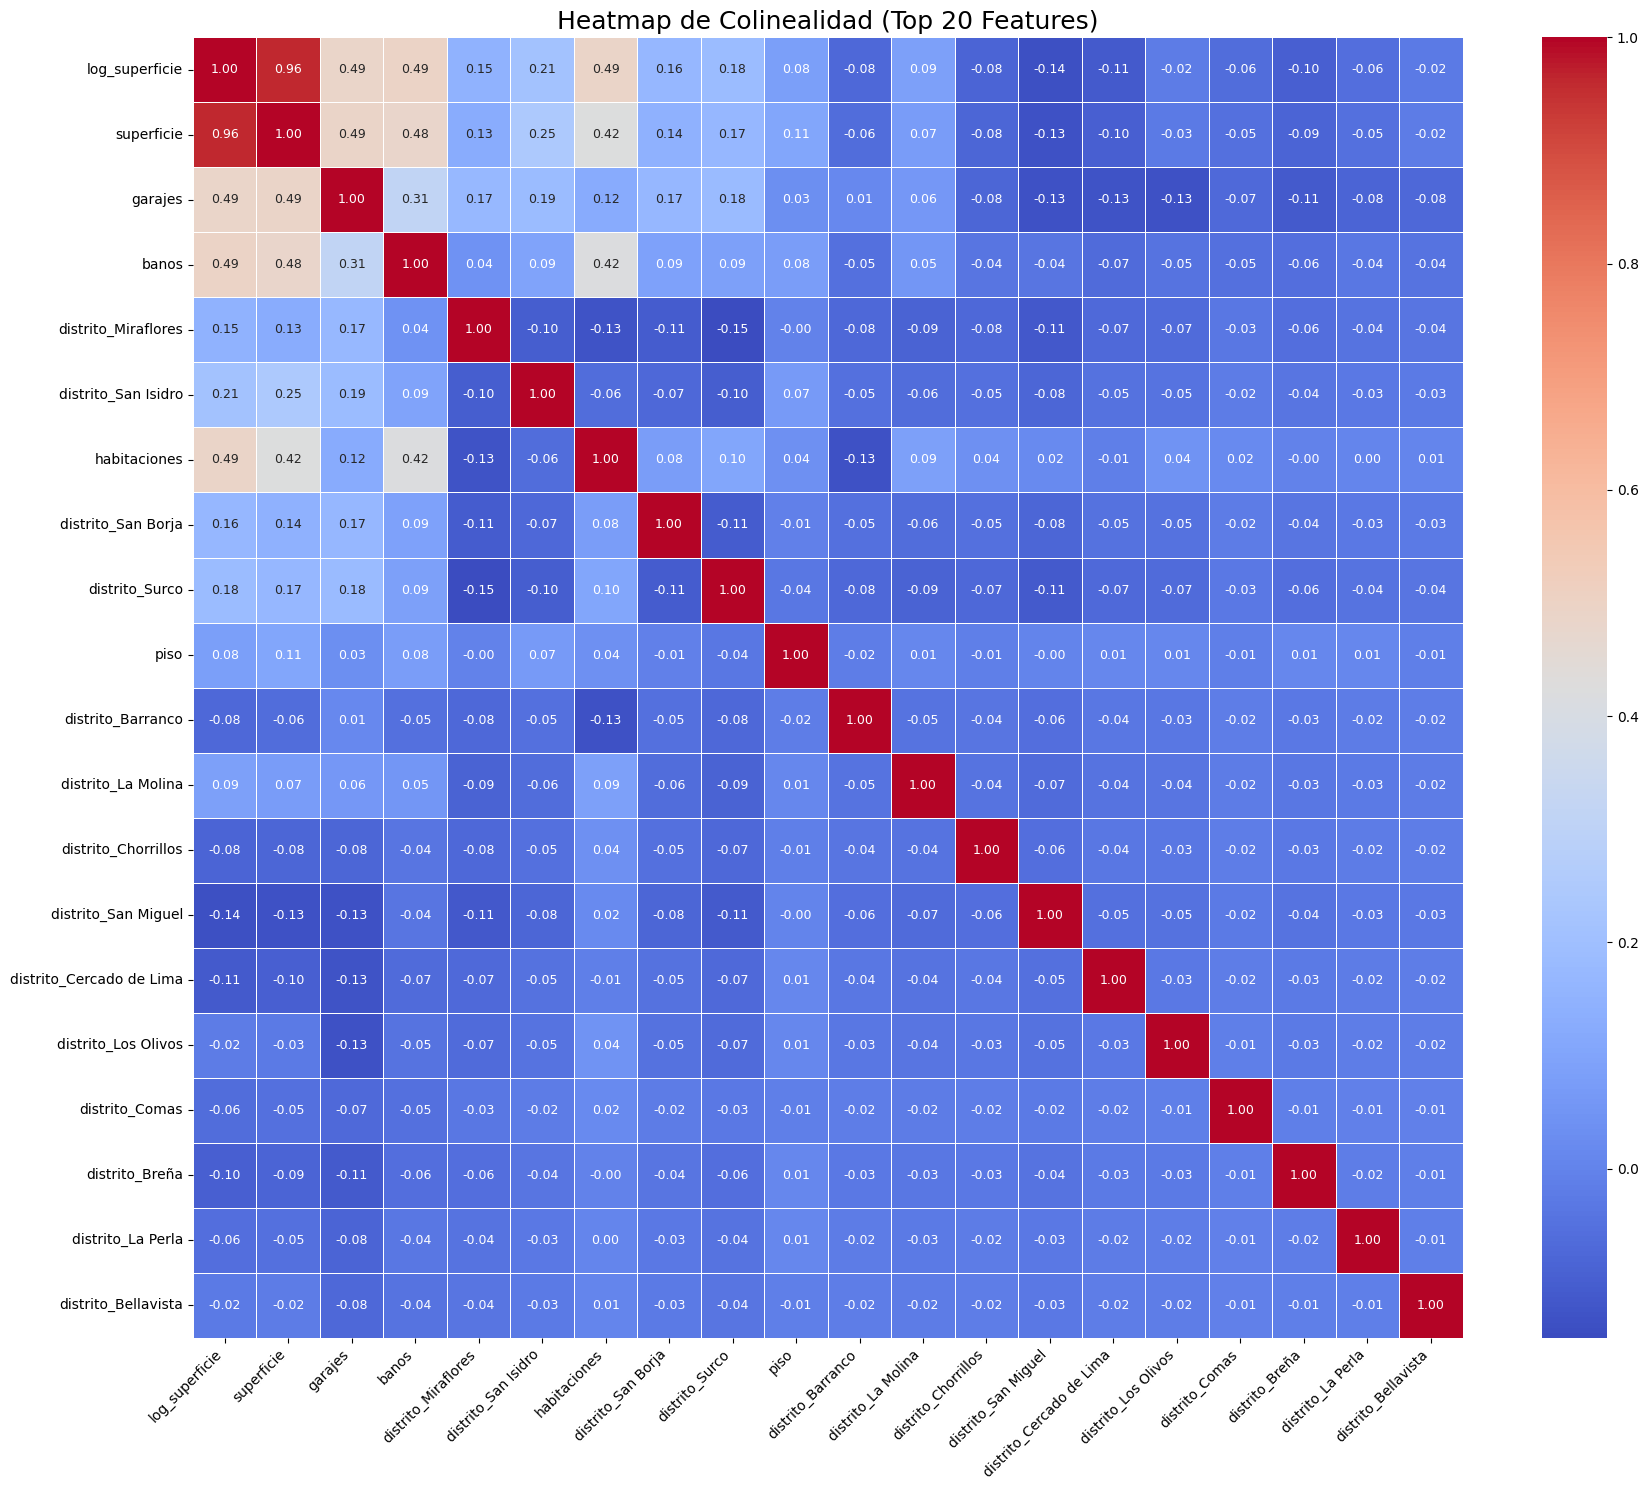


¡Éxito! Heatmap guardado como 'collinearity_heatmap.png'
Por favor, revisa el gráfico para identificar 'cajas' de color rojo oscuro o azul oscuro.


In [4]:

print("--- PASO 3: Detección de Colinealidad (Heatmap) ---")

# 1. Definir la lista de las ~20 features más predictivas
# Esta lista se basa en los resultados del Paso 2.
# Seleccionamos las Top 12 positivas y las Top 8 negativas.

# Top 12 positivas (de tu lista del Paso 2)
top_features_list = [
    'log_superficie',
    'superficie',
    'garajes',
    'banos',
    'distrito_Miraflores',
    'distrito_San Isidro',
    'habitaciones',
    'distrito_San Borja',
    'distrito_Surco',
    'piso',
    'distrito_Barranco',
    'distrito_La Molina'
]

# Top 8 negativas (de tu lista del Paso 2)
bottom_features_list = [
    'distrito_Chorrillos',
    'distrito_San Miguel',
    'distrito_Cercado de Lima',
    'distrito_Los Olivos',
    'distrito_Comas',
    'distrito_Breña',
    'distrito_La Perla',
    'distrito_Bellavista'
]

heatmap_cols = top_features_list + bottom_features_list
print(f"Seleccionando {len(heatmap_cols)} features para el heatmap de colinealidad.")

# 2. Filtrar el DataFrame y calcular la matriz de correlación del subconjunto
# Nos aseguramos de que todas las columnas existan antes de proceder
missing_cols = [col for col in heatmap_cols if col not in df.columns]
if missing_cols:
    print(f"\nError de KeyError: Las siguientes columnas no se encontraron en el DataFrame:")
    print(missing_cols)
    print("Por favor, verifica los nombres en 'top_features_list' y 'bottom_features_list'.")
else:
    df_subset = df[heatmap_cols]
    corr_subset = df_subset.corr()

    # 3. Generar el heatmap
    print("Generando heatmap...")
    plt.figure(figsize=(18, 15))

    sns.heatmap(
        corr_subset,
        annot=True,         # Mostrar los números (coeficientes)
        cmap='coolwarm',    # Usar un mapa de color divergente (azul-blanco-rojo)
        fmt='.2f',          # Formatear los números a 2 decimales
        linewidths=0.5,     # Añadir líneas delgadas entre celdas
        annot_kws={"size": 9} # Ajustar tamaño de fuente para que quepa
    )

    plt.title('Heatmap de Colinealidad (Top 20 Features)', fontsize=18)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout() # Ajustar para evitar que las etiquetas se corten

    # 4. Guardar el gráfico y mostrarlo
    file_name = "collinearity_heatmap.png"
    plt.savefig(file_name)
    plt.show() # Mostrar el gráfico en el notebook

    print(f"\n¡Éxito! Heatmap guardado como '{file_name}'")
    print("Por favor, revisa el gráfico para identificar 'cajas' de color rojo oscuro o azul oscuro.")

In [5]:
print("--- PASO 4: Cálculo del Factor de Inflación de la Varianza (VIF) ---")

# 1. DEFINIR LAS VARIABLES FEATURES (PREDICTORAS)
# Excluiremos las variables de precio/target y las económicas (leakage/colineales)
# También quitamos 'superficie' porque 'log_superficie' es la que usaremos
variables_a_excluir_vif = [
    'log_precio', 'precio_target', 'precio_usd', 'precio_soles_corrientes',
    'precio_m2_target', 'log_precio_m2', 'precio_m2_usd',
    'anio', 'ipc', 'tipo_cambio',
    'superficie' # Excluimos superficie original, preferimos log_superficie
]

# Crear el DataFrame 'X' solo con las features predictoras
X_features = df.drop(columns=variables_a_excluir_vif, errors='ignore')

# Asegurarnos de que todas las columnas restantes son numéricas
X_features = X_features.select_dtypes(include=np.number)

# VIF requiere que no haya valores NaN, aunque ya deberíamos haberlos tratado
X_features.fillna(X_features.mean(), inplace=True)

# Añadir una constante para el cálculo del VIF (requerido por statsmodels)
X_with_const = add_constant(X_features)

print(f"Calculando VIF para {X_features.shape[1]} variables predictoras...")

# 2. CALCULAR EL VIF PARA CADA FEATURE
# Creamos un DataFrame para almacenar los resultados
vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(X_with_const.shape[1])]

# Quitamos la fila de la constante ('const'), no nos interesa su VIF
vif_data = vif_data[vif_data["feature"] != 'const']

# Ordenar por VIF descendente para ver las más problemáticas primero
vif_data.sort_values(by='VIF', ascending=False, inplace=True)

# 3. MOSTRAR LOS RESULTADOS
print("\n" + "="*60)
print(" Factor de Inflación de la Varianza (VIF) por Variable")
print(" (Valores > 5 o 10 indican alta multicolinealidad)")
print("="*60)

print("\n--- Variables con VIF más ALTO (Potencialmente Problemáticas) ---")
print(vif_data.head(10))

print("\n--- Variables con VIF más BAJO (Saludables) ---")
print(vif_data.tail(10))

# 4. (Opcional) Mostrar todas las variables si no son muchas
print("\n--- VIF Completo ---")
print(vif_data)

--- PASO 4: Cálculo del Factor de Inflación de la Varianza (VIF) ---
Calculando VIF para 28 variables predictoras...

 Factor de Inflación de la Varianza (VIF) por Variable
 (Valores > 5 o 10 indican alta multicolinealidad)

--- Variables con VIF más ALTO (Potencialmente Problemáticas) ---
                  feature       VIF
21    distrito_Miraflores  8.049289
26         distrito_Surco  7.808670
25    distrito_San Miguel  5.281298
23     distrito_San Borja  5.015666
24    distrito_San Isidro  4.966478
20     distrito_Magdalena  4.364457
27     distrito_Surquillo  4.296373
15     distrito_La Molina  3.919786
14   distrito_Jesús María  3.833021
22  distrito_Pueblo Libre  3.661534

--- Variables con VIF más BAJO (Saludables) ---
                 feature       VIF
1           habitaciones  1.659432
17  distrito_La Victoria  1.628211
3                garajes  1.557619
8    distrito_Bellavista  1.545367
2                  banos  1.493281
13        distrito_Comas  1.417342
10   distrito_Carab

In [6]:
print("\n" + "="*70)
print(" PASO 5: Resumen Ejecutivo y Estrategia de Modelado Final")
print("="*70)

print("\nEste es el resumen de todo el análisis de correlación (Pasos 1-4).")
print("A continuación, se definen las listas de variables exactas que debes")
print("usar en tu próximo notebook de 'Model Training'.")

# ======================================================================
# --- 1. Variable Objetivo (Target 'y') ---
# ======================================================================

target_variable = 'log_precio'

print("\n\n--- 1. Variable Objetivo (Target 'y') ---")
print("Esta es la ÚNICA variable que tu modelo debe ser entrenado para predecir.")
print("\n[Justificación]:")
print("Se usa 'log_precio' (y no 'precio_target') porque el análisis de")
print("distribución mostró que tiene una forma de campana (Gaussiana),")
print("lo cual es ideal para la mayoría de los modelos de regresión.")

print("\n# -> Variable Target para 'y':")
print(f"target_variable = '{target_variable}'")


# ======================================================================
# --- 2. Variables Descartadas (Fuga de Datos y Redundancia) ---
# ======================================================================

variables_descartadas = [
    'log_precio',          # Es el target
    'precio_target',       # Fuga de datos (base del target)
    'precio_usd',          # Fuga de datos
    'precio_soles_corrientes', # Fuga de datos
    'precio_m2_target',    # Fuga de datos (derivado)
    'log_precio_m2',       # Fuga de datos (derivado)
    'precio_m2_usd',       # Fuga de datos (derivado)
    'anio',                # Colinealidad económica
    'ipc',                 # Colinealidad económica
    'tipo_cambio',         # Colinealidad económica
    'superficie'           # Redundante (se usa 'log_superficie')
]

print("\n\n--- 2. Variables Descartadas (Para Excluir de 'X') ---")
print("Estas variables NUNCA deben ser usadas como features (predictoras 'X')")
print("porque 'contaminarían' el modelo y darían resultados falsos.")

print("\n[Justificación del descarte]:")
print(" A) FUGA DE DATOS (Data Leakage): (Paso 1)")
print("    - Son variaciones del propio target: 'log_precio', 'precio_target', 'precio_usd', etc.")
print(" B) COLINEALIDAD ECONÓMICA: (Paso 1)")
print("    - Miden lo mismo (el tiempo) y son colineales: 'anio', 'ipc', 'tipo_cambio'.")
print(" C) REDUNDANCIA DE FEATURE: (Paso 4)")
print("    - 'superficie' es redundante. 'log_superficie' es mejor y no colineal (VIF = 2.29).")


print("\n# -> Lista de variables a excluir de 'X':")
print("discarded_variables = [")
for i in range(0, len(variables_descartadas), 2):
    sub_list = variables_descartadas[i:i+2]
    formatted_list = [f"'{f}'" for f in sub_list]
    line_content = ", ".join(formatted_list)
    print(f"    {line_content},")
print("]")


# ======================================================================
# --- 3. Variables Predictoras Finales (Features 'X') ---
# ======================================================================

# (Esta es la lista de 28 features de tu resultado del VIF en el Paso 4)
final_features_list = [
    'distrito_Miraflores', 'distrito_Surco', 'distrito_San Miguel',
    'distrito_San Borja', 'distrito_San Isidro', 'distrito_Magdalena',
    'distrito_Surquillo', 'distrito_La Molina', 'distrito_Jesús María',
    'distrito_Pueblo Libre', 'distrito_Lince', 'distrito_Barranco',
    'distrito_Chorrillos', 'distrito_Cercado de Lima', 'distrito_Los Olivos',
    'log_superficie', 'distrito_Breña', 'distrito_La Perla',
    'habitaciones', 'distrito_La Victoria', 'garajes',
    'distrito_Bellavista', 'banos', 'distrito_Comas',
    'distrito_Carabayllo', 'antiguedad', 'piso',
    'vista_exterior'
]
final_features_list.sort() # Ordenar alfabéticamente para legibilidad

print("\n\n--- 3. Variables Predictoras Finales (Features 'X') ---")
print(f"Se han validado {len(final_features_list)} features finales para el modelo.")
print("Estas son las variables que SÍ debes usar para entrenar el modelo.")

print("\n[Justificación de la selección]:")
print(" A) PODER PREDICTIVO: (Paso 2)")
print("    - Mostraron la correlación más fuerte con 'log_precio'.")
print("    - Top 3: 'log_superficie', 'garajes', 'banos'.")
print(" B) SALUDABLES (SIN COLINEALIDAD): (Pasos 3 y 4)")
print("    - El VIF confirmó que ninguna feature clave es redundantemente colineal.")
print("    - 'log_superficie' (VIF=2.29), 'habitaciones' (VIF=1.66) y 'banos' (VIF=1.49)")
print("      son saludables y aportan valor único.")
print("    - Los VIFs de los distritos son aceptables (<10) y capturan el valor de la ubicación.")


print("\n# -> Lista de features finales para 'X':")
print("final_features = [")
for i in range(0, len(final_features_list), 3):
    sub_list = final_features_list[i:i+3]
    formatted_list = [f"'{f}'" for f in sub_list]
    line_content = ", ".join(formatted_list)
    print(f"    {line_content},")
print("]")


 PASO 5: Resumen Ejecutivo y Estrategia de Modelado Final

Este es el resumen de todo el análisis de correlación (Pasos 1-4).
A continuación, se definen las listas de variables exactas que debes
usar en tu próximo notebook de 'Model Training'.


--- 1. Variable Objetivo (Target 'y') ---
Esta es la ÚNICA variable que tu modelo debe ser entrenado para predecir.

[Justificación]:
Se usa 'log_precio' (y no 'precio_target') porque el análisis de
distribución mostró que tiene una forma de campana (Gaussiana),
lo cual es ideal para la mayoría de los modelos de regresión.

# -> Variable Target para 'y':
target_variable = 'log_precio'


--- 2. Variables Descartadas (Para Excluir de 'X') ---
Estas variables NUNCA deben ser usadas como features (predictoras 'X')
porque 'contaminarían' el modelo y darían resultados falsos.

[Justificación del descarte]:
 A) FUGA DE DATOS (Data Leakage): (Paso 1)
    - Son variaciones del propio target: 'log_precio', 'precio_target', 'precio_usd', etc.
 B) COLINEA

In [8]:
print("--- Fase 2: Modelado - Paso 2: División de Datos (Train/Test Split) ---")

# 1. Definir las listas de Target y Features (de nuestro análisis - Paso 5)

# 1a. Variable Objetivo (Target 'y')
target_variable = 'log_precio'

# 1b. Variables Predictoras (Features 'X')
# (Las 28 variables que validamos con Correlación y VIF)
final_features = [
    'antiguedad', 'banos', 'distrito_Barranco',
    'distrito_Bellavista', 'distrito_Breña', 'distrito_Carabayllo',
    'distrito_Cercado de Lima', 'distrito_Chorrillos', 'distrito_Comas',
    'distrito_Jesús María', 'distrito_La Molina', 'distrito_La Perla',
    'distrito_La Victoria', 'distrito_Lince', 'distrito_Los Olivos',
    'distrito_Magdalena', 'distrito_Miraflores', 'distrito_Pueblo Libre',
    'distrito_San Borja', 'distrito_San Isidro', 'distrito_San Miguel',
    'distrito_Surco', 'distrito_Surquillo', 'garajes',
    'habitaciones', 'log_superficie', 'piso',
    'vista_exterior'
]

print(f"\nDefiniendo 'y' (Target) como: '{target_variable}'")
print(f"Definiendo 'X' (Features) con {len(final_features)} columnas.")

# 2. Crear los DataFrames X e y
# Verificar que todas las features existan antes de crear X
missing_cols = [col for col in final_features if col not in df.columns]
if missing_cols:
    print(f"Error: Las siguientes features no se encontraron en el CSV: {missing_cols}")
else:
    X = df[final_features]
    y = df[target_variable]

    # 3. Realizar la división (80% train, 20% test)
    # test_size=0.2 significa 20% para el conjunto de prueba
    # random_state=42 es un número fijo para asegurar que la división
    # sea siempre la misma. Esto es CRUCIAL para que tus resultados sean reproducibles.

    print("\nDividiendo los datos (80% train, 20% test) con random_state=42...")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # 4. Verificar los resultados (muy importante)
    print("\n¡División completada! Formas de los DataFrames:")
    print(f"X_train (features de entrenamiento): {X_train.shape}")
    print(f"y_train (target de entrenamiento):  {y_train.shape}")
    print(f"X_test (features de prueba):        {X_test.shape}")
    print(f"y_test (target de prueba):          {y_test.shape}")


--- Fase 2: Modelado - Paso 2: División de Datos (Train/Test Split) ---

Definiendo 'y' (Target) como: 'log_precio'
Definiendo 'X' (Features) con 28 columnas.

Dividiendo los datos (80% train, 20% test) con random_state=42...

¡División completada! Formas de los DataFrames:
X_train (features de entrenamiento): (43816, 28)
y_train (target de entrenamiento):  (43816,)
X_test (features de prueba):        (10954, 28)
y_test (target de prueba):          (10954,)
